In [125]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection  import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

In [59]:
df = pd.read_csv("credit_card_fraud_dataset.csv")

In [60]:
print(df.shape)
print(df.describe())
print(df.info())





(100000, 7)
       TransactionID         Amount     MerchantID        IsFraud
count  100000.000000  100000.000000  100000.000000  100000.000000
mean    50000.500000    2497.092666     501.676070       0.010000
std     28867.657797    1442.415999     288.715868       0.099499
min         1.000000       1.050000       1.000000       0.000000
25%     25000.750000    1247.955000     252.000000       0.000000
50%     50000.500000    2496.500000     503.000000       0.000000
75%     75000.250000    3743.592500     753.000000       0.000000
max    100000.000000    4999.770000    1000.000000       1.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   TransactionID    100000 non-null  int64  
 1   TransactionDate  100000 non-null  object 
 2   Amount           100000 non-null  float64
 3   MerchantID       100000 non-null  int64  
 4 

In [61]:
df.head(1)

,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0


In [74]:
df.isnull().sum()

,0
TransactionID,0
TransactionDate,0
Amount,0
MerchantID,0
IsFraud,0
TransactionType_refund,0
Location_Dallas,0
Location_Houston,0
Location_Los Angeles,0
Location_New York,0


In [64]:
df = pd.get_dummies(df, columns=["Location"], drop_first=True)

In [82]:
df = df.drop(columns=["MerchantID"])

In [85]:
x = df.drop(columns=["IsFraud"])
y = df["IsFraud"]


In [86]:
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])

df["Hour"] = df["TransactionDate"].dt.hour
df["Day"] = df["TransactionDate"].dt.day
df["Month"] = df["TransactionDate"].dt.month
df["DayOfWeek"] = df["TransactionDate"].dt.dayofweek

df = df.drop(columns=["TransactionDate"])

In [114]:

x = df.drop(columns=["IsFraud"])

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [117]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(x_scaled)

In [118]:
df["Cluster"] = clusters

In [120]:
df.groupby("Cluster").mean()

,Amount,IsFraud,TransactionType_refund,Location_Dallas,Location_Houston,Location_Los Angeles,Location_New York,Location_Philadelphia,Location_Phoenix,Location_San Antonio,Location_San Diego,Location_San Jose,Hour,Day,Month,DayOfWeek
Cluster,,,,,,,,,,,,,,,,
0,2484.659923,0.009839,0.497416,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,11.477639,15.682469,6.523753,3.016796
1,2501.218775,0.009751,0.507087,0.000000,0.000000,0.499397,0.000000,0.000000,0.500603,0.0,0.000000,0.000000,11.531614,15.760806,6.476478,2.995527
2,2497.706657,0.010094,0.500228,0.143857,0.142643,0.000000,0.142672,0.140958,0.000000,0.0,0.144356,0.139987,11.495431,15.802633,6.526456,3.023186


In [121]:
pd.crosstab(df["Cluster"], y)

IsFraud,0,1
Cluster,,
0,9963,99
1,19702,194
2,69335,707


In [122]:
def label_cluster(x):
    if x == 2:
        return "High Risk"
    elif x == 1:
        return "Medium Risk"
    else:
        return "Low Risk"

df["RiskLevel"] = df["Cluster"].apply(label_cluster)

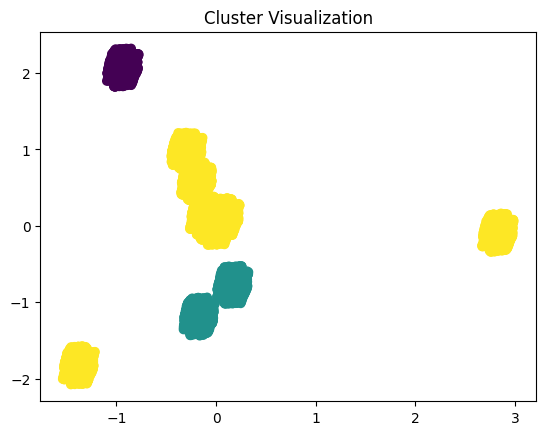

In [124]:


pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=df["Cluster"])
plt.title("Cluster Visualization")
plt.show()

In [127]:
##DBSCAN model
dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters = dbscan.fit_predict(x_scaled)

df["Cluster"] = clusters

In [128]:
df.groupby("Cluster")["IsFraud"].mean()

,IsFraud
Cluster,
-1,0.009862
0,0.000000
1,0.000000
2,0.000000
3,0.000000
...,...
2312,0.000000
2313,0.000000
2314,0.000000


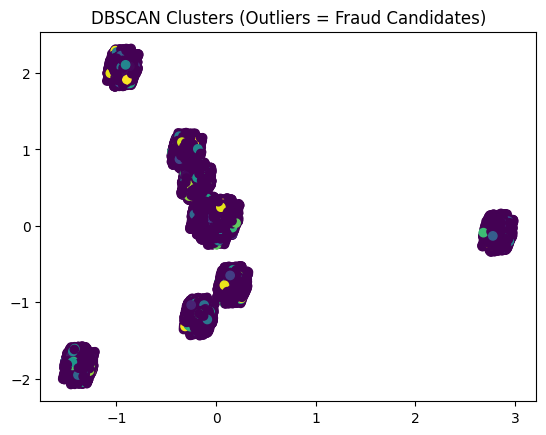

In [130]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=df["Cluster"])
plt.title("DBSCAN Clusters (Outliers = Fraud Candidates)")
plt.show()